In [1]:
%reload_ext autoreload
%autoreload 2

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

# Import packages that will be used
import c2qa
from custom_gates import state_transfer
import numpy as np
import matplotlib.pyplot as plt
from qiskit import ClassicalRegister, visualization, AncillaRegister,QuantumRegister
from qiskit_aer.noise import NoiseModel, amplitude_damping_error
from qiskit.quantum_info import state_fidelity, Statevector
from qiskit.quantum_info.operators import Operator
from qiskit.quantum_info.operators.predicates import is_unitary_matrix
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library.standard_gates import HGate
from math import pi, ceil
import scipy
from c2qa.operators import CVOperators
from c2qa.qumoderegister import QumodeRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from c2qa.parameterized_unitary_gate import ParameterizedUnitaryGate
from qutip import *

In [2]:
cutoff = 2**3
osc_init = coherent(cutoff,-2) + coherent(cutoff,2)

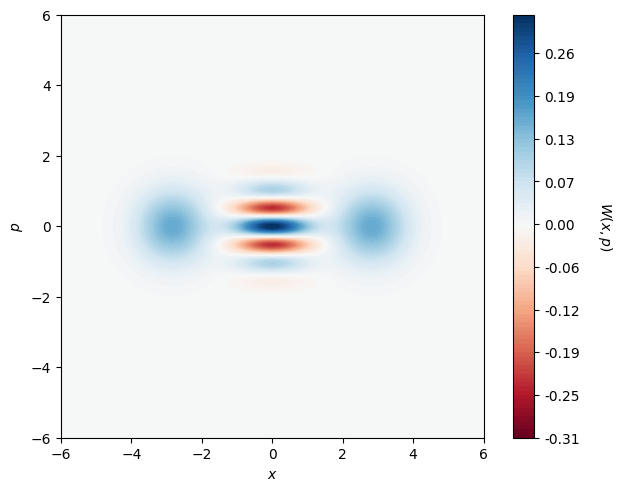

In [216]:
qbm = 4
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode = 6)
qbr = QuantumRegister(1)
qbr1 = QuantumRegister(4)
cr = ClassicalRegister(1)
cr1 = ClassicalRegister(4)
circuit = c2qa.CVCircuit(qmr, qbr1, cr1)
circuit.cv_initialize(osc_init.full(), qmr[0])

state3, result, _ = c2qa.util.simulate(circuit,shots = 1024)
c2qa.wigner.plot_wigner(circuit, state3)

/Users/shubdeepmohapatra/Desktop/CV-DV-Benchmarking-/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/shubdeepmohapatra/Desktop/CV-DV-Benchmarking-/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/Users/shubdeepmohapatra/Desktop/CV-DV-Benchmarking-/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:597: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/Users/shubdeepmohapatra/Desktop/CV-DV-Benchmarking-/.venv/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


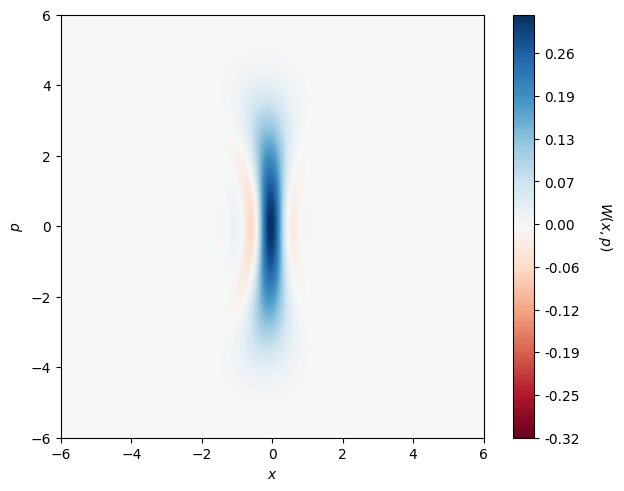

In [100]:
def apply_basis_transformation(circuit, qbr1):
    num_qubits = len(qbr1)
    for i in range(num_qubits):
        circuit.h(qbr1[i])
        if i == num_qubits - 1:  # MSB
            circuit.x(qbr1[i])
            circuit.z(qbr1[i])
        elif i == 0:  # LSB
            circuit.z(qbr1[i])
        else:  # Middle qubits
            circuit.x(qbr1[i])

# Initialize the circuit
n = 4
lmbda = 0.38
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode=6)
qbr1 = QuantumRegister(n)
cr1 = ClassicalRegister(n)
circuit = c2qa.CVCircuit(qmr, qbr1, cr1)

# Initialize the CV qumode
circuit.cv_initialize(0, qmr[0])

# Add the CV-to-DV transfer gate
for i in (range(1,n+1)):
        circuit.sdg(qbr1[i-1])
        circuit.h(qbr1[i-1])
        alpha_j = (np.pi )/ (2**(i+1) * lmbda )
        circuit.cv_ecd(1j*alpha_j/np.sqrt(2),qmr[0],qbr1[i-1])
        circuit.h(qbr1[i-1])
        circuit.s(qbr1[i-1])
        
        circuit.h(qbr1[i-1])
        beta_j = -lmbda*2**(i-1)
        if i == n:
            beta_j = -beta_j
        circuit.cv_ecd(beta_j/np.sqrt(2),qmr[0],qbr1[i-1])
        circuit.h(qbr1[i-1])



# Apply basis transformation
apply_basis_transformation(circuit, qbr1)


circuit.barrier()

# Simulate and measure
st0 = Statevector.from_instruction(circuit)
for i in range(len(qbr1)):
    circuit.measure(qbr1[i], cr1[-(i + 1)])

state1, result, _ = c2qa.util.simulate(circuit, shots=2048)
c2qa.wigner.plot_wigner(circuit, state1)

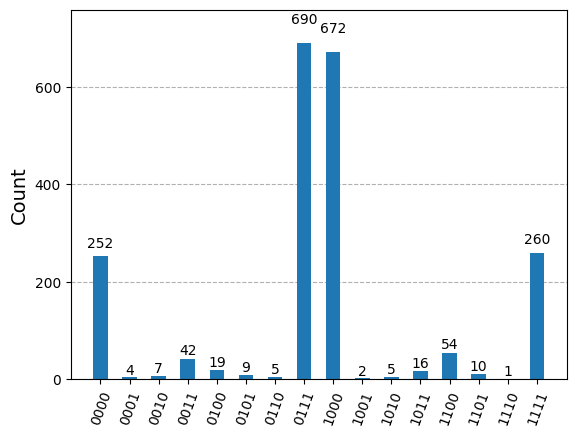

In [101]:
plot_histogram(result.get_counts())

Cat State

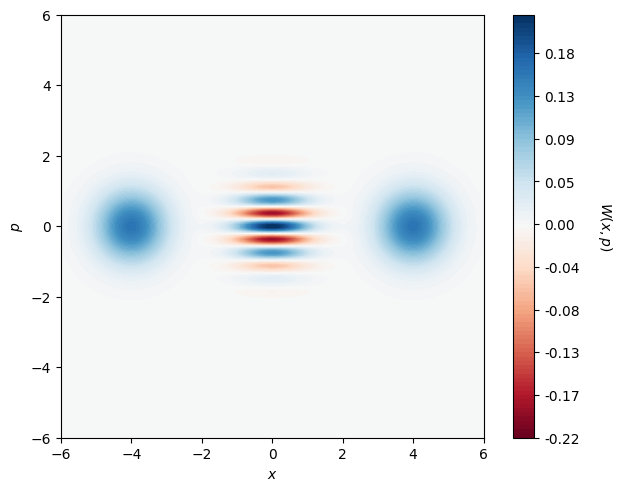

In [ ]:
Nmodes=1
Nqubits = 1 
cutoff = 2**6
alpha = 4

qmr = c2qa.QumodeRegister(num_qumodes=1, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))),name='qumode')
qbr = QuantumRegister(Nqubits,name='qubit')
cbr = ClassicalRegister(Nqubits)
circuit = c2qa.CVCircuit(qmr, qbr,cbr)

circuit.h(qbr[0])
circuit.cv_c_d(alpha / np.sqrt(2),qmr[0],qbr[0])
circuit.h(qbr[0])

circuit.sdg(qbr[0])
circuit.h(qbr[0])
circuit.cv_c_d(1j*np.pi/(8*alpha*np.sqrt(2)),qmr[0],qbr[0])
circuit.h(qbr[0])
circuit.s(qbr[0])

stateop, result, _ = c2qa.util.simulate(circuit,shots = 1024)

fig = c2qa.wigner.plot_wigner(circuit, stateop)

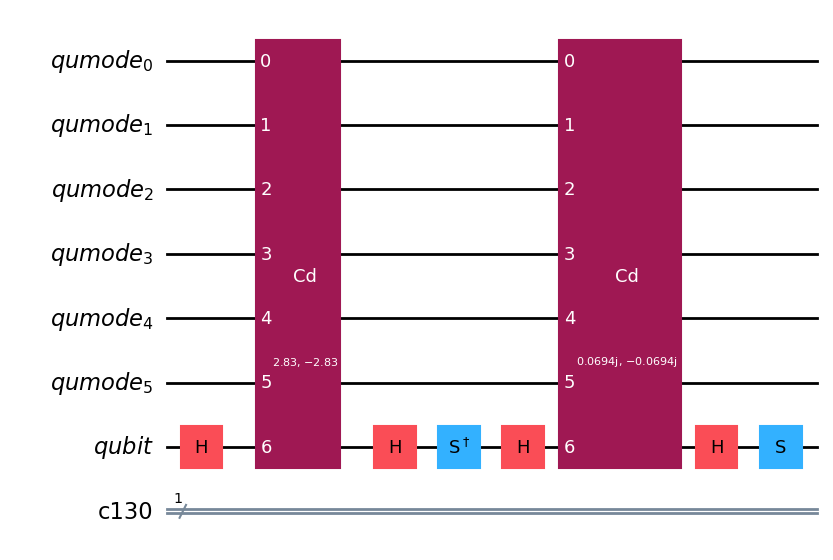

In [212]:
circuit.draw('mpl')

GKP State

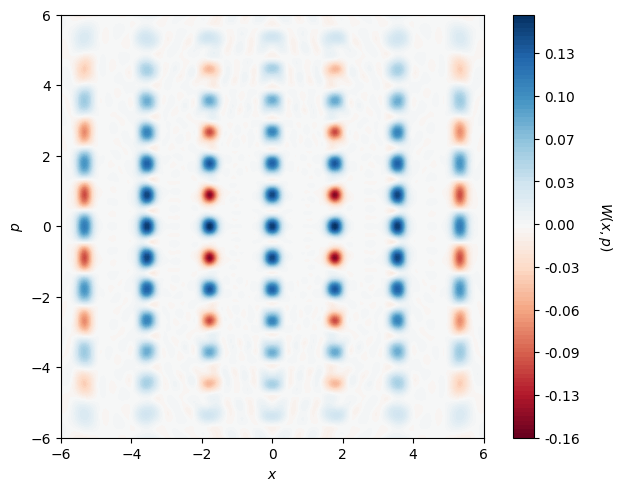

In [ ]:
Nmodes=1
Nqubits = 1 
cutoff = 2**6
alpha = np.sqrt(pi)
theta = np.sqrt(pi)
delta = 0.222
N_rounds = 9
r = -np.log(delta) 


qmr = c2qa.QumodeRegister(num_qumodes=1, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))))
qbr = QuantumRegister(Nqubits)
cbr = ClassicalRegister(Nqubits)
circuit = c2qa.CVCircuit(qmr, qbr,cbr)
circuit.cv_sq(r,qmr[0])

for k in range(1,N_rounds):
    circuit.h(qbr[0])
    circuit.cv_c_d(alpha / np.sqrt(2),qmr[0],qbr[0])
    circuit.h(qbr[0])

    circuit.sdg(qbr[0])
    circuit.h(qbr[0])
    circuit.cv_c_d(1j*np.pi/(8*alpha*np.sqrt(2)),qmr[0],qbr[0])
    circuit.h(qbr[0])
    circuit.s(qbr[0])
    
stateop, result, _ = c2qa.util.simulate(circuit,shots = 1024)

fig = c2qa.wigner.plot_wigner(circuit, stateop)
